# Building the 2D FESTIM heat-exchanger permeation model — step by step

This notebook rebuilds `hx_2d_model.py` from scratch, one concept at a time, so you can
see *why* each piece exists. Run it in your `festim2` conda environment, from the
`Heat Exchanger Model/` folder (it imports `hx_thermal_sizing`, `material_library`, etc.).

**What you'll learn**

1. What the 2D domain actually is (the unrolled tube wall) and how to mesh it with dolfinx
2. How FESTIM subdomains work in 2D (locator functions instead of `Subdomain1D`)
3. The three unit conversions between our material library and FESTIM
4. The UFL "gotcha": why the temperature field must be symbolic, not interpolated
5. Assembling and solving `HydrogenTransportProblem` in 2D
6. Turning a 2D `SurfaceFlux` into a plant-level number (Ci/day) and checking it against the stitched-1D Phase 3 result

**The mental picture.** All 1,183 tubes are identical, so we model ONE tube wall and
multiply by the bundle at the end. That wall is cut lengthwise and unrolled flat:
a rectangle 14.7 m long (axial, `z`) by 2.5 mm thick (through-wall, `y`). He + T₂ touch
the `y=0` face, steam touches the `y=t_wall` face. Aspect ratio ≈ 5,900:1 — every plot
below exaggerates `y` or it would be invisible.

In [1]:
# Step 0 — imports and the Phase-0 design
# (everything non-FESTIM first, so failures are easy to localise)
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')   # IN617 T-range extrapolation warning — known, documented

from hx_thermal_sizing import size_hx
from material_library import get_material, M_T, M_H
from axial_integration import integrate_hx

design, prof = size_hx(verbose=False)     # the thermally-sized geometry
L     = design['L_m']
t_w   = design['inputs']['t_wall']
d_i   = design['inputs']['d_i']
N     = design['n_tubes']
perim = N * np.pi * d_i

print(f"Domain: {L:.2f} m x {t_w*1e3:.1f} mm   (aspect ratio {L/t_w:,.0f}:1)")
print(f"Bundle: {N} tubes -> total wetted perimeter {perim:.1f} m")
print(f"Area:   {design['A_m2']:.0f} m2 at U = {design['U_W_m2K']:.0f} W/m2/K")

Domain: 14.43 m x 2.5 mm   (aspect ratio 5,771:1)
Bundle: 1183 tubes -> total wetted perimeter 37.2 m
Area:   536 m2 at U = 201 W/m2/K


## Step 1 — the mesh

FESTIM 1D has `F.Mesh1D(vertices=...)`. In 2D you build the mesh yourself with
**dolfinx** and hand it to FESTIM via `F.Mesh(mesh=...)`.

Cell counts encode the physics: the concentration profile through the wall is nearly
linear (steady diffusion), so ~16 cells in `y` is plenty; along `z` the flux varies by
three orders of magnitude, so we want a few hundred cells. Quadrilaterals suit this
stretched geometry better than triangles.

6400 cells; cell size 36 mm (axial) x 156 um (through-wall)


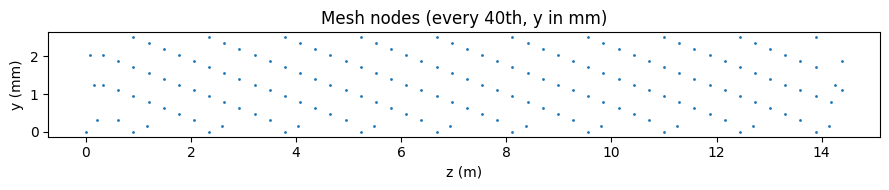

In [2]:
import festim as F
import dolfinx
from mpi4py import MPI

NZ, NY = 400, 16

fenics_mesh = dolfinx.mesh.create_rectangle(
    MPI.COMM_WORLD,
    [[0.0, 0.0], [L, t_w]],            # corners: (z, y)
    [NZ, NY],
    cell_type=dolfinx.mesh.CellType.quadrilateral,
)
print(f"{NZ*NY} cells; cell size {L/NZ*1e3:.0f} mm (axial) x {t_w/NY*1e6:.0f} um (through-wall)")

# look at it (y exaggerated ~400x, else the slab is a hairline)
coords = fenics_mesh.geometry.x
fig, ax = plt.subplots(figsize=(9, 2))
ax.scatter(coords[::40, 0], coords[::40, 1]*1e3, s=1)
ax.set(xlabel='z (m)', ylabel='y (mm)', title='Mesh nodes (every 40th, y in mm)')
plt.tight_layout(); plt.show()

## Step 2 — subdomains by locator

In 1D, `SurfaceSubdomain1D(x=0)` is enough. In 2D, FESTIM needs a **locator**: a
function that takes coordinate arrays `x` (shape `(3, n_points)`) and returns a boolean
mask marking which points belong to that boundary. He side = the `y=0` edge, steam
side = the `y=t_w` edge. The volume locator marks everything.

Sanity-check locators *before* solving — a locator that matches zero facets fails
silently and gives you a wrong answer, not an error.

In [3]:
mat_props = get_material('Inconel617')   # used in Step 3; needed for Material now
KJMOL_TO_EV = 1.0 / 96.485

def make_festim_material(**kw):
    """F.Material across FESTIM 2.x variants (some require an `id` arg)."""
    try:
        return F.Material(**kw)
    except TypeError:
        return F.Material(id=1, **kw)

inconel = make_festim_material(
    D_0=mat_props['D0'] / np.sqrt(M_T / M_H),   # see Step 3
    E_D=mat_props['ED'] * KJMOL_TO_EV,
)

vol   = F.VolumeSubdomain(id=1, material=inconel,
                          locator=lambda x: np.full_like(x[0], True, dtype=bool))
s_he  = F.SurfaceSubdomain(id=2, locator=lambda x: np.isclose(x[1], 0.0))
s_sec = F.SurfaceSubdomain(id=3, locator=lambda x: np.isclose(x[1], t_w))

# verify each boundary locator finds the expected number of facets
for name, sd in [('He side (y=0)', s_he), ('steam side (y=t_w)', s_sec)]:
    n = len(dolfinx.mesh.locate_entities_boundary(fenics_mesh, 1, sd.locator))
    print(f"{name:20s}: {n} facets  (expect {NZ})")

He side (y=0)       : 400 facets  (expect 400)
steam side (y=t_w)  : 400 facets  (expect 400)


## Step 3 — material properties and the three unit conversions

Our `material_library` follows Shimada's conventions; FESTIM has its own. Three
conversions, all easy to get silently wrong:

| Quantity | Library | FESTIM | Conversion |
|---|---|---|---|
| Solubility | `K_S` in mol(T₂)/m³/Pa⁰·⁵ | atomic: mol(T)/m³/Pa⁰·⁵ | `S_0 = 2 × KS0` (each T₂ → 2 atoms) |
| Energies | kJ/mol, `exp(-E/RT)` | eV, `exp(-E/k_B T)` | × 1/96.485 |
| Diffusivity | protium `D_H` | tritium | `D_T = D_H / √(m_T/m_H) ≈ D_H/√3` |

The bookkeeping consequence: FESTIM's concentrations and fluxes are **atomic**, so at
the very end we divide `SurfaceFlux` by 2 to get back to mol T₂.

In [4]:
S_0  = 2.0 * mat_props['KS0']                 # mol T / m3 / Pa^0.5
E_S  = mat_props['ES'] * KJMOL_TO_EV          # eV
D_0T = mat_props['D0'] / np.sqrt(M_T / M_H)   # m2/s
E_D  = mat_props['ED'] * KJMOL_TO_EV          # eV

print(f"S_0  = {S_0:.3f} mol T/m3/Pa^0.5    E_S = {E_S:.4f} eV")
print(f"D_0T = {D_0T:.3e} m2/s            E_D = {E_D:.4f} eV")

# spot-check at the hot end (580 C): FESTIM's c_surface and the analytical flux
kB, T = 8.617e-5, 580 + 273.15
c_s = S_0 * np.exp(-E_S/(kB*T)) * np.sqrt(10.0)
D   = D_0T * np.exp(-E_D/(kB*T))
print(f"\nAt 580 C, p=10 Pa:  c_surf = {c_s:.3e} mol T/m3,  "
      f"J = D*c/t = {D*c_s/t_w/2:.3e} mol T2/m2/s")
print("(compare hx_1d_model analytical: 1.93e-08 — should match)")

S_0  = 11.620 mol T/m3/Pa^0.5    E_S = 0.3990 eV
D_0T = 7.516e-07 m2/s            E_D = 0.5244 eV

At 580 C, p=10 Pa:  c_surf = 1.614e-01 mol T/m3,  J = D*c/t = 1.936e-08 mol T2/m2/s
(compare hx_1d_model analytical: 1.93e-08 — should match)


## Step 4 — the temperature field, and the UFL gotcha

In 1D we passed `temperature=873.15` (a number). Here the wall temperature varies with
**both** coordinates, and FESTIM accepts a *callable of position*. The trap: FESTIM
calls it with a **symbolic UFL coordinate** while building the weak form — not numbers.
So anything that needs real values (`np.interp`, table lookups, `if x > ...`) raises the
`Indexed.__float__` error you saw. Only symbolic-safe operations survive: `+ - * /`,
powers, and `ufl.exp`/`ufl.sin`/etc.

Luckily the Phase-0 counterflow profile **is** analytic:

$$ a(z) = \tfrac{A}{L}z, \qquad \Delta T(z) = \Delta T_0\, e^{-r a}, \qquad r = U\left(\tfrac{1}{C_h} - \tfrac{1}{C_c}\right) $$
$$ T_{He}(z) = T_{h,in} - \tfrac{U}{C_h}\,\Delta T_0 \tfrac{1 - e^{-ra}}{r}, \qquad
   T(z, y) = T_{He} - \tfrac{U\Delta T}{h_{He}} - \tfrac{U \Delta T}{k_w}\,y $$

The last two terms drop from the gas temperature to the He-side wall surface (the big
step — the He film holds 93% of the thermal resistance) and then linearly through the
metal. **Always verify the symbolic formula against its numpy twin** before solving.

max |closed form - Phase 0 profile| = 2.27e-13 K  (must be ~1e-13)


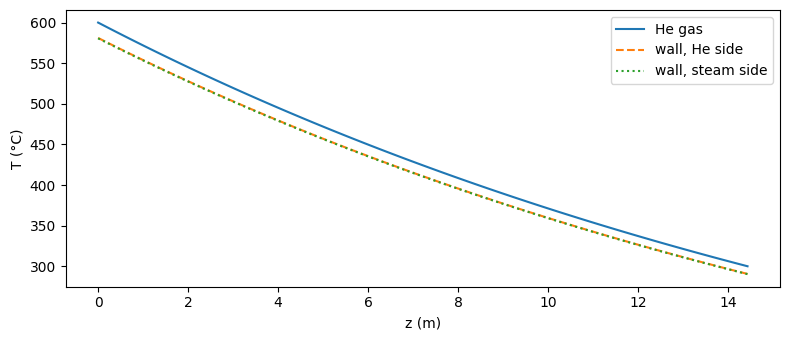

In [5]:
import ufl

inp  = design['inputs']
U, A   = design['U_W_m2K'], design['A_m2']
C_h, C_c = design['C_hot_W_K'], design['C_cold_W_K']
h_he, k_w = design['h_he_W_m2K'], inp['k_wall']
dT0  = inp['T_h_in'] - inp['T_c_out']
r_cf = U * (1.0/C_h - 1.0/C_c)

def temperature(x):                       # x is SYMBOLIC here
    a    = (A / L) * x[0]
    dT   = dT0 * ufl.exp(-r_cf * a)
    T_he = inp['T_h_in'] - (U/C_h) * dT0 * (1 - ufl.exp(-r_cf*a)) / r_cf
    return T_he - (U*dT/h_he) - (U*dT/k_w) * x[1]

# numpy twin for verification + plotting
def temperature_np(z, y):
    a    = (A / L) * z
    dT   = dT0 * np.exp(-r_cf * a)
    T_he = inp['T_h_in'] - (U/C_h) * dT0 * (1 - np.exp(-r_cf*a)) / r_cf
    return T_he - (U*dT/h_he) - (U*dT/k_w) * y

err = np.max(np.abs(temperature_np(prof['z_m'], 0.0) - prof['T_wall_he_K']))
print(f"max |closed form - Phase 0 profile| = {err:.2e} K  (must be ~1e-13)")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(prof['z_m'], prof['T_he_K']-273.15, label='He gas')
ax.plot(prof['z_m'], temperature_np(prof['z_m'], 0.0)-273.15, '--', label='wall, He side')
ax.plot(prof['z_m'], temperature_np(prof['z_m'], t_w)-273.15, ':', label='wall, steam side')
ax.set(xlabel='z (m)', ylabel='T (°C)'); ax.legend(); plt.tight_layout(); plt.show()

## Step 5 — species, boundary conditions, export

Same trio as every permeation problem:

- **He side (`y=0`)** — `SievertsBC`: dissolved concentration in equilibrium with the
  10 Pa T₂ over the metal, `c = S(T)·√p`. Temperature-dependent through the field above.
- **Steam side (`y=t_w`)** — `FixedConcentrationBC(value=0)`: perfect sink (tritium
  oxidises to HTO in steam and is carried off).
- **Export** — `SurfaceFlux` on the *steam* side: what escapes, which is the answer.

The short edges (`z=0`, `z=L`) get no BC → FESTIM's default is zero flux, which is
correct: no tritium leaves through the tube-sheet ends.

In [6]:
tritium = F.Species('T')

bcs = [
    F.SievertsBC(subdomain=s_he, S_0=S_0, E_S=E_S, pressure=10.0, species=tritium),
    F.FixedConcentrationBC(subdomain=s_sec, value=0.0, species=tritium),
]
flux_out = F.SurfaceFlux(field=tritium, surface=s_sec)
print("BCs and export defined.")

BCs and export defined.


## Step 6 — assemble and solve

Steady state (`transient=False`), tight tolerances. This is a linear-ish problem on a
6,400-cell mesh — it should solve in seconds.

In [7]:
import time

model = F.HydrogenTransportProblem(
    mesh=F.Mesh(mesh=fenics_mesh),
    subdomains=[vol, s_he, s_sec],
    species=[tritium],
    boundary_conditions=bcs,
    exports=[flux_out],
    temperature=temperature,
    settings=F.Settings(atol=1e-12, rtol=1e-12, transient=False),
)
t0 = time.time()
model.initialise()
model.run()
print(f"Solved in {time.time()-t0:.1f} s")

ld: warning: duplicate -rpath '/Users/emre/anaconda3/envs/festim2/lib' ignored
ld: warning: duplicate -rpath '/Users/emre/anaconda3/envs/festim2/lib' ignored


Solved in 2.8 s


## Step 7 — from a line integral to Ci/day

In 2D, `SurfaceFlux` is the flux integrated **along the boundary edge**, per unit depth
into the page: units mol T / (m·s). The "depth" of our slab is the unrolled tube
circumference — for the whole bundle, the wetted perimeter `N·π·d_i`. So:

$$ Q_T = \tfrac{1}{2} \times |\text{SurfaceFlux}| \times N \pi d_i $$

(the ½ converts atoms → T₂ molecules). Then compare against Phase 3, which integrated
the *1D* flux model station-by-station — agreement within a few % validates the
stitched-1D approximation.

In [8]:
J_line = abs(flux_out.data[-1])          # mol T / m / s
Q_T2_2d = 0.5 * J_line * perim           # mol T2 / s

# IMPORTANT: this 2D model is a Cartesian SLAB, so compare like-for-like
# against Phase 3 in slab mode. The production number uses
# geometry='cylindrical' (exact annular wall, ~23% higher).
r3_slab = integrate_hx(quiet=True, geometry='slab')
r3_cyl  = integrate_hx(quiet=True)              # cylindrical (default)

BQ_PER_MOL_T = np.log(2)/(12.32*3.1557e7) * 6.02214e23
to_ci_day = lambda q: 2*q * BQ_PER_MOL_T / 3.7e10 * 86400

print(f"2D FESTIM (slab)        : {Q_T2_2d:.4e} mol T2/s = {to_ci_day(Q_T2_2d):,.0f} Ci/day")
print(f"Phase 3   (slab)        : {r3_slab['Q_T2_mol_s']:.4e} mol T2/s")
print(f"stitching error         : {abs(Q_T2_2d-r3_slab['Q_T2_mol_s'])/r3_slab['Q_T2_mol_s']:.2%}")
print(f"Phase 3   (cylindrical) : {r3_cyl['Q_T2_mol_s']:.4e} mol T2/s = {to_ci_day(r3_cyl['Q_T2_mol_s']):,.0f} Ci/day  <- production value")

2D FESTIM (slab)        : 1.7164e-06 mol T2/s = 8,606 Ci/day
Phase 3   (slab)        : 1.7143e-06 mol T2/s
stitching error         : 0.12%
Phase 3   (cylindrical) : 2.1140e-06 mol T2/s = 10,600 Ci/day  <- production value


## Step 8 — look at the solution

The dissolved-tritium field. Expect: concentration highest at the hot-end He surface
(top-left in this orientation), dropping linearly through the wall, and collapsing by
orders of magnitude toward the cold end. This is the picture behind "50% of the leak
in the first 12% of the length".

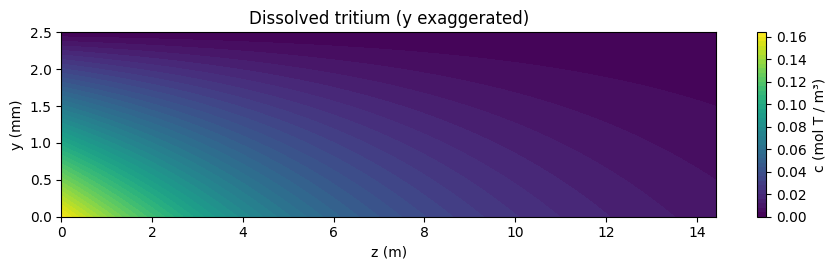

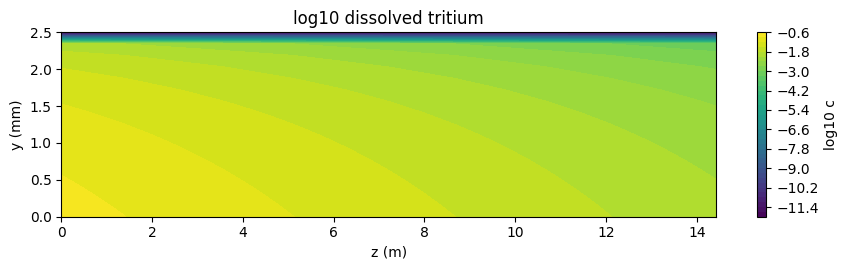

In [9]:
c_sol = tritium.post_processing_solution
xyz   = c_sol.function_space.mesh.geometry.x
c     = c_sol.x.array

fig, ax = plt.subplots(figsize=(9, 2.8))
tc = ax.tricontourf(xyz[:, 0], xyz[:, 1]*1e3, c, levels=40)
fig.colorbar(tc, label='c (mol T / m³)')
ax.set(xlabel='z (m)', ylabel='y (mm)', title='Dissolved tritium (y exaggerated)')
plt.tight_layout(); plt.show()

# the same field on a log scale tells the axial story better
fig, ax = plt.subplots(figsize=(9, 2.8))
tc = ax.tricontourf(xyz[:, 0], xyz[:, 1]*1e3, np.log10(np.maximum(c, 1e-12)), levels=40)
fig.colorbar(tc, label='log10 c')
ax.set(xlabel='z (m)', ylabel='y (mm)', title='log10 dissolved tritium')
plt.tight_layout(); plt.show()

## Exercises

1. **Mesh convergence.** Wrap Steps 1–7 in a function of `(NZ, NY)` and run
   `(100,8) → (200,12) → (400,16) → (800,24)`. Plot Q_T vs cell count. Which direction
   matters more, and why? (Hint: where is the solution non-linear?)
2. **Oxidised wall.** Multiply `S_0` by 0.01 (the INL oxide suppression factor enters
   through solubility here). Predict the answer before running — why is it exactly ×100?
3. **Cylindrical correction.** The slab underestimates by ~19% because the wall is thick
   relative to the bore (2.5 mm on r_i = 5 mm). The production code handles this exactly via
   `effective_thickness()` (`t_eff = r_i·ln(r_o/r_i)` = 2.03 mm). Derive that formula yourself
   from steady diffusion in an annulus (solve `(1/r)(r c')' = 0`), then verify it numerically
   with `compute_flux_festim_cylindrical()` from `hx_1d_model` — a cylindrical 1D FESTIM solve
   with manual flux extraction (FESTIM's `SurfaceFlux` is Cartesian-only).
4. **Reversed exchanger.** Swap the flow arrangement so the steam inlet (290 °C) meets the
   He inlet (600 °C) — i.e. co-current. Rebuild `temperature(x)` (the co-current profile has
   `r = U(1/C_h + 1/C_c)` and a different ΔT₀) and see what it does to Q_T and to the LMTD.
5. **Transient start-up.** Set `transient=True` with a `Stepsize` (copy the pattern from your
   pebble model) and watch the breakthrough time — how long before the steam side sees
   tritium after a cold start? Compare with the lag-time estimate `t_lag = t_w²/(6D)` at 580 °C.

**Where things live:** Phase 0 sizing in `hx_thermal_sizing.py`, the 1D model and unit
conversions in `hx_1d_model.py`, the sweep in `run_flux_map.py`, plant-level integration in
`axial_integration.py`, this model's script form in `hx_2d_model.py`, figures in `hx_plots.py`.